In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
df = pd.read_csv('MSFT.csv')

# Convert 'date' to datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Create 'daily_return' column
df['daily_return'] = df['close'].pct_change()

# Create output folder for saving visuals
output_dir = 'EDA_Visuals'
os.makedirs(output_dir, exist_ok=True)

# 1. Line plot of closing price over time
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['close'], label='Close Price')
plt.title('MSFT Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/01_Close_Price_Trend.png')
plt.close()

# 2. Histogram of daily returns
plt.figure(figsize=(10,6))
sns.histplot(df['daily_return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f'{output_dir}/02_Daily_Return_Distribution.png')
plt.close()

# 3. Volume trend over time
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['volume'], color='orange')
plt.title('MSFT Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{output_dir}/03_Trading_Volume.png')
plt.close()

# Add calendar features
df['weekday'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month_name()

# 4. Boxplot of daily returns by weekday
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='weekday', y='daily_return', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
plt.title('Daily Returns by Weekday')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{output_dir}/04_Returns_by_Weekday.png')
plt.close()

# 5. Boxplot of daily returns by month
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='month', y='daily_return', order=month_order)
plt.title('Daily Returns by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{output_dir}/05_Returns_by_Month.png')
plt.close()


# Create target
df['return'] = df['close'].pct_change()
df['target'] = (df['return'].shift(-1) > 0).astype(int)

# Feature Engineering
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_20'] = df['close'].rolling(window=20).mean()
df['ma_ratio_5_20'] = df['ma_5'] / df['ma_20']

df['momentum_3'] = df['close'] - df['close'].shift(3)
df['momentum_7'] = df['close'] - df['close'].shift(7)

df['std_20'] = df['close'].rolling(window=20).std()
df['bollinger_width'] = 4 * df['std_20'] / df['ma_20']

delta = df['close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(window=14).mean()
avg_loss = pd.Series(loss).rolling(window=14).mean()
rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

df['volume_change'] = df['volume'].pct_change()
df['price_gap'] = df['close'] - df['open']
df['rsi_volatility_interaction'] = df['rsi_14'] * df['std_20']

# Drop missing values
df = df.dropna().reset_index(drop=True)

# Create output directory
eda_dir = "EDA_Charts"
os.makedirs(eda_dir, exist_ok=True)

# List of features to plot
features = [
    'rsi_14', 'momentum_3', 'momentum_7', 'bollinger_width',
    'macd', 'macd_signal', 'price_gap', 'rsi_volatility_interaction'
]

# Boxplots by target
for feat in features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='target', y=feat)
    plt.title(f'{feat} by Next-Day Movement')
    plt.tight_layout()
    plt.savefig(f"{eda_dir}/{feat}_boxplot_by_target.png")
    plt.close()

# KDE plot for momentum_3
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['target'] == 1]['momentum_3'], label='Up', shade=True)
sns.kdeplot(df[df['target'] == 0]['momentum_3'], label='Down', shade=True)
plt.title("KDE of Momentum_3 by Target")
plt.legend()
plt.tight_layout()
plt.savefig(f"{eda_dir}/momentum_3_kde_by_target.png")
plt.close()

# Line plot of MA ratio
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['ma_ratio_5_20'], label='MA Ratio (5/20)')
plt.title("MA Ratio (5/20) Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{eda_dir}/ma_ratio_5_20_trend.png")
plt.close()


C:\Users\RSM\AppData\Local\Temp\ipykernel_33200\2607806114.py:134: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['target'] == 1]['momentum_3'], label='Up', shade=True)
C:\Users\RSM\AppData\Local\Temp\ipykernel_33200\2607806114.py:135: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['target'] == 0]['momentum_3'], label='Down', shade=True)


In [37]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("MSFT.csv")

# Parse and sort date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# ===============================
# Target Variable (Binary Classification)
# ===============================
df['return'] = df['close'].pct_change()
df['target'] = (df['return'].shift(-1) > 0).astype(int)

# ===============================
# Moving Averages
# ===============================
df['ma_5'] = df['close'].rolling(window=5).mean()
df['ma_10'] = df['close'].rolling(window=10).mean()
df['ma_50'] = df['close'].rolling(window=50).mean()
df['ma_200'] = df['close'].rolling(window=200).mean()

# ===============================
# Volatility (Rolling Std Dev)
# ===============================
df['std_5'] = df['close'].rolling(window=5).std()
df['std_10'] = df['close'].rolling(window=10).std()
df['std_20'] = df['close'].rolling(window=20).std()

# ===============================
# Volume-Based Features
# ===============================
df['volume_change'] = df['volume'].pct_change()
df['volume_ma_5'] = df['volume'].rolling(window=5).mean()

# ===============================
# Price-Based Features
# ===============================
df['price_gap'] = df['close'] - df['open']
df['close_to_ma50'] = (df['close'] - df['ma_50']) / df['ma_50']

# ===============================
# Volatility Regime Flag
# ===============================
df['volatility_regime'] = (df['std_10'] > df['std_10'].mean()).astype(int)

# ===============================
# Calendar Features
# ===============================
df['weekday'] = df['date'].dt.weekday  # 0 = Monday
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

# ===============================
# Momentum Features
# ===============================
df['momentum_3'] = df['close'] - df['close'].shift(3)
df['momentum_7'] = df['close'] - df['close'].shift(7)

# ===============================
# Moving Average Gap
# ===============================
df['ma_gap_5_20'] = df['ma_5'] - df['ma_20'] if 'ma_20' in df.columns else df['ma_5'] - df['close'].rolling(20).mean()

# ===============================
# RSI (Relative Strength Index)
# ===============================
delta = df['close'].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)
avg_gain = pd.Series(gain).rolling(window=14).mean()
avg_loss = pd.Series(loss).rolling(window=14).mean()
rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))
df['rsi_flag'] = df['rsi_14'].apply(lambda x: 1 if x < 30 else (-1 if x > 70 else 0))

# ===============================
# Bollinger Bands
# ===============================
rolling_mean_20 = df['close'].rolling(window=20).mean()
rolling_std_20 = df['close'].rolling(window=20).std()
df['bollinger_upper'] = rolling_mean_20 + (2 * rolling_std_20)
df['bollinger_lower'] = rolling_mean_20 - (2 * rolling_std_20)
df['bollinger_width'] = df['bollinger_upper'] - df['bollinger_lower']

# ===============================
# Price Standardized Z-Ratio
# ===============================
df['price_std_ratio'] = (df['close'] - df['close'].rolling(20).mean()) / df['close'].rolling(20).std()

# ===============================
# Price Relative to 10-Day Range
# ===============================
df['rolling_max_10'] = df['close'].rolling(10).max()
df['rolling_min_10'] = df['close'].rolling(10).min()
df['close_to_range'] = (df['close'] - df['rolling_min_10']) / (df['rolling_max_10'] - df['rolling_min_10'])

# Close relative to MA200
df['close_to_ma200'] = (df['close'] - df['ma_200']) / df['ma_200']

# Rolling returns
df['rolling_return_3'] = df['close'].pct_change(periods=3)
df['rolling_return_7'] = df['close'].pct_change(periods=7)

# RSI × Volatility interaction
df['rsi_volatility_interaction'] = df['rsi_14'] * df['std_10']


# ===============================
# Drop NA from Rolling Windows
# ===============================
df_clean = df.dropna().reset_index(drop=True)

feature_cols = [
    'ma_5', 'ma_10', 'ma_50', 'ma_200',
    'std_5', 'std_10', 'std_20',
    'volume_change', 'volume_ma_5',
    'price_gap', 'return',
    'close_to_ma50', 'close_to_ma200',
    'rolling_return_3', 'rolling_return_7',
    'momentum_3', 'momentum_7',
    'rsi_14', 'rsi_volatility_interaction',
    'volatility_regime', 'bollinger_width',
    'price_std_ratio', 'close_to_range',
    'weekday', 'month', 'day',
    'ma_gap_5_20',
    'rsi_flag',
    'rolling_max_10', 'rolling_min_10',
    'open', 'high', 'low', 'close', 'volume'
]

X = df_clean[feature_cols]
y = df_clean['target']


# Confirm shapes
print("Final Dataset Shape:", df_clean.shape)
print("Feature Columns:", df_clean.columns.tolist())


Final Dataset Shape: (9670, 39)
Feature Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'return', 'target', 'ma_5', 'ma_10', 'ma_50', 'ma_200', 'std_5', 'std_10', 'std_20', 'volume_change', 'volume_ma_5', 'price_gap', 'close_to_ma50', 'volatility_regime', 'weekday', 'month', 'day', 'momentum_3', 'momentum_7', 'ma_gap_5_20', 'rsi_14', 'rsi_flag', 'bollinger_upper', 'bollinger_lower', 'bollinger_width', 'price_std_ratio', 'rolling_max_10', 'rolling_min_10', 'close_to_range', 'close_to_ma200', 'rolling_return_3', 'rolling_return_7', 'rsi_volatility_interaction']



Top 10 Most Highly Correlated Feature Pairs:

            Feature 1        Feature 2  Correlation
686   bollinger_width           std_20     1.000000
223            std_20  bollinger_width     1.000000
1051             open              low     0.999947
1118              low             open     0.999947
1120              low            close     0.999946
1154            close              low     0.999946
1084             high             open     0.999946
1050             open             high     0.999946
1086             high            close     0.999944
1153            close             high     0.999944


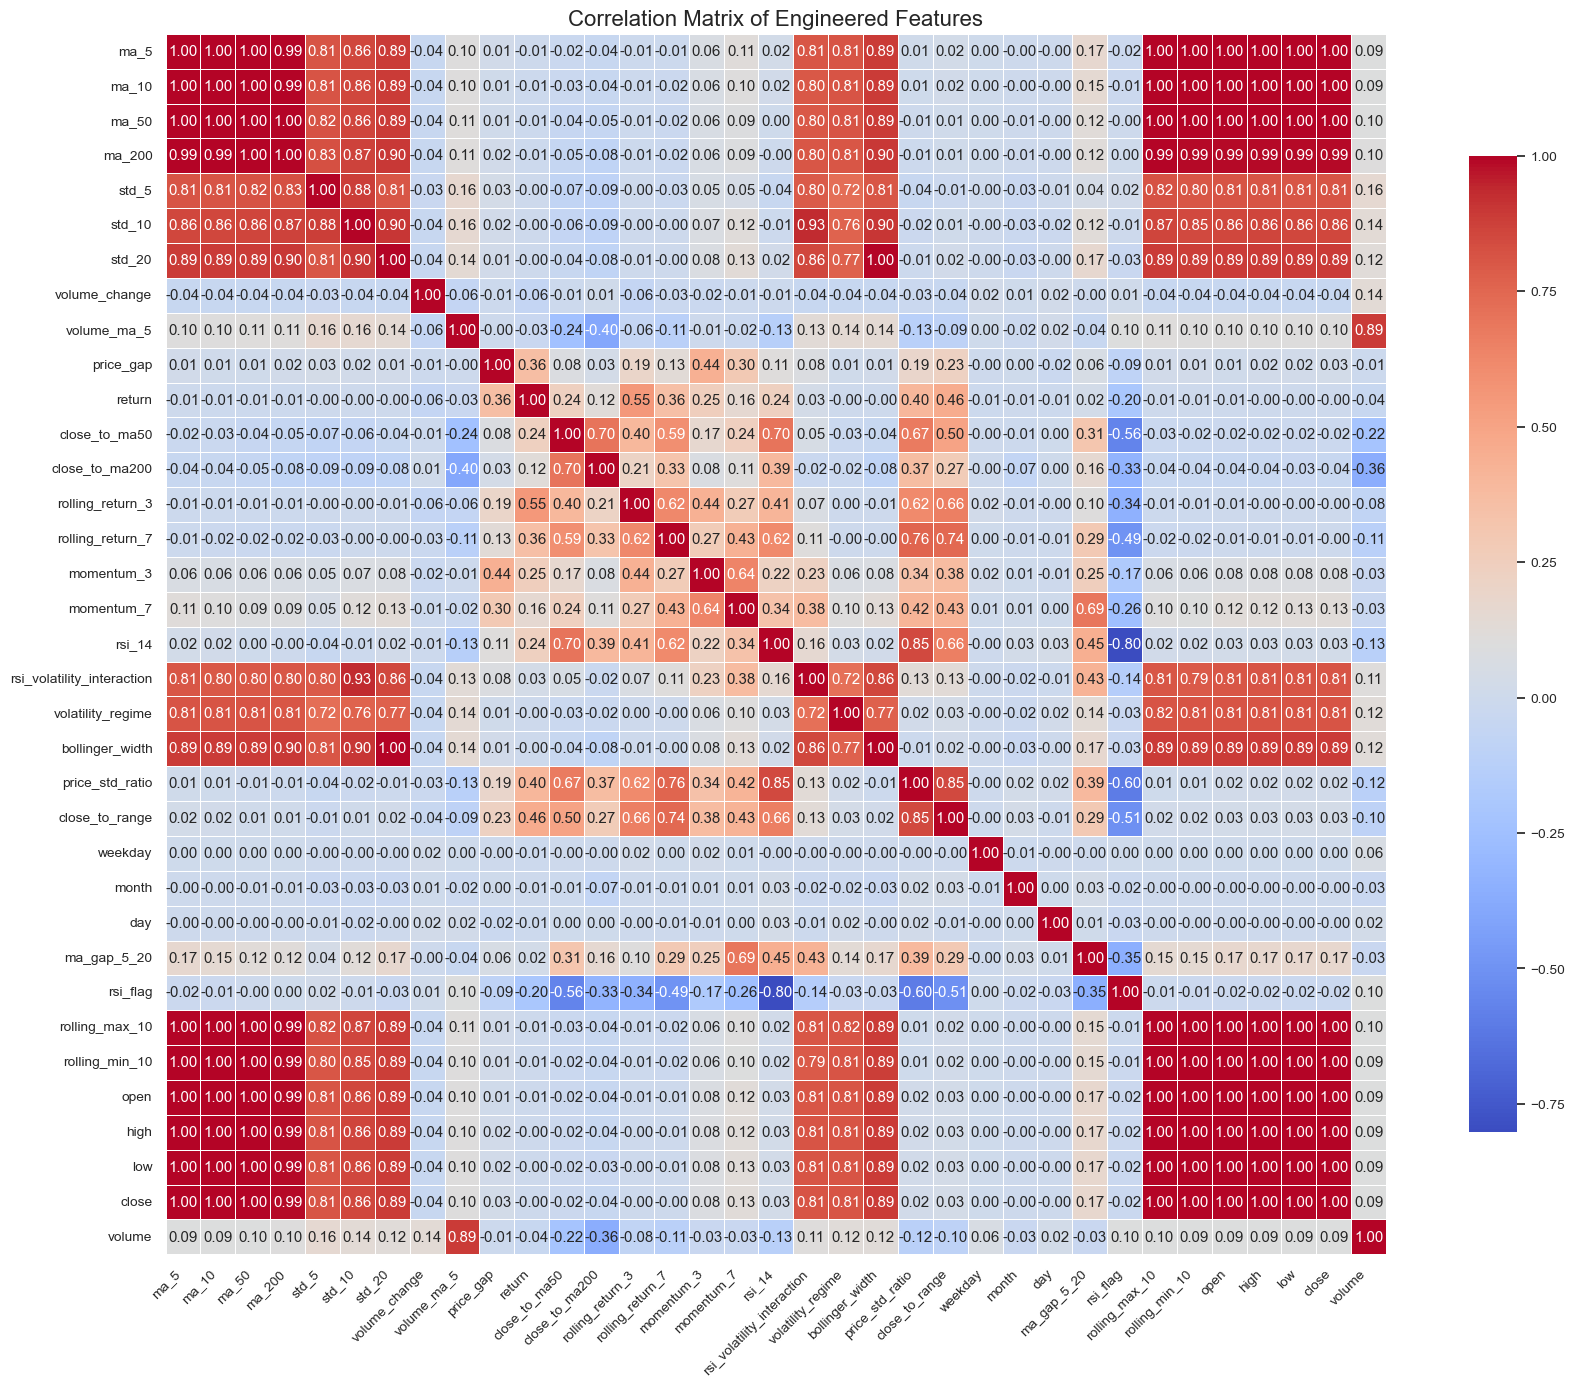

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = X.corr()

# Identify and display top correlated pairs (excluding self-correlation)
mask = ~np.eye(correlation_matrix.shape[0], dtype=bool)
correlation_pairs = correlation_matrix.where(mask).stack().reset_index()
correlation_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
correlation_pairs['AbsCorrelation'] = correlation_pairs['Correlation'].abs()
top_correlations = correlation_pairs.sort_values(by='AbsCorrelation', ascending=False).head(10)

# Print top 10 highly correlated pairs
print("\nTop 10 Most Highly Correlated Feature Pairs:\n")
print(top_correlations[['Feature 1', 'Feature 2', 'Correlation']])

# Plot heatmap (with improvements)
plt.figure(figsize=(18, 14))
sns.set(font_scale=0.9)  # Smaller font size for readability
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha='right')
plt.title("Correlation Matrix of Engineered Features", fontsize=16)
plt.tight_layout()
plt.show()



In [39]:
# STEP 1: Compute correlation matrix
correlation_matrix = X.corr().abs()  # Absolute correlation for threshold comparison

# STEP 2: Create upper triangle matrix of correlations
upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# STEP 3: Identify columns to drop (any feature with correlation > 0.85)
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

# Print features that will be removed
print("Features to drop due to high correlation (> 0.85):")
print(to_drop)

# STEP 4: Drop from dataset
X_reduced = X.drop(columns=to_drop)

# Confirm new shape
print(f"\nOriginal feature count: {X.shape[1]}")
print(f"Reduced feature count: {X_reduced.shape[1]}")

correlation_matrix.to_csv("correlation_matrix.csv", index=True)

# Melt the matrix into long format
corr_long = correlation_matrix.reset_index().melt(id_vars='index')
corr_long.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_long.to_csv("correlation_matrix_long.csv", index=False)


Features to drop due to high correlation (> 0.85):
['ma_10', 'ma_50', 'ma_200', 'std_10', 'std_20', 'rsi_volatility_interaction', 'bollinger_width', 'close_to_range', 'rolling_max_10', 'rolling_min_10', 'open', 'high', 'low', 'close', 'volume']

Original feature count: 35
Reduced feature count: 20


c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, ite


=== Model Evaluation Summary - Reduced Feature Set ===
  Model   ROC AUC  CV ROC AUC  Accuracy  Precision    Recall  F1 Score
0    LR  0.509523    0.522397  0.510858   0.546203  0.570201  0.557944
1   LDA  0.509398    0.522483  0.510858   0.546203  0.570201  0.557944
2   KNN  0.515148    0.506201  0.495863   0.554217  0.351480  0.430158
3  CART  0.533785    0.507659  0.537746   0.571831  0.581662  0.576705
4    NB  0.532219    0.505115  0.481903   0.587549  0.144222  0.231595
5   SVM  0.502451    0.525975  0.472079   0.630000  0.060172  0.109852
6    RF  0.543728    0.516342  0.504137   0.595238  0.262655  0.364480
7   XGB  0.519188    0.519688  0.499483   0.564228  0.331423  0.417569


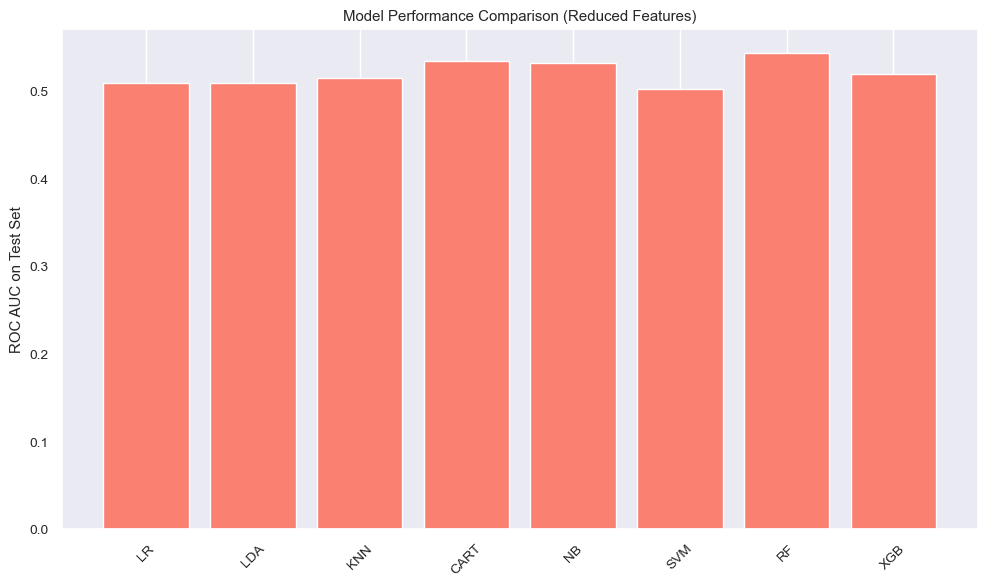

In [40]:
#Model Building Initial First Run Using 10 KFold Cross Validation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import matplotlib.pyplot as plt

# OPTIONAL: Uncomment if lightgbm is installed
# import lightgbm as lgb

# Target variable
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Drop rows with missing values
df.dropna(inplace=True)

# Assumes X_reduced has already been defined using correlation filtering
# It should be aligned with df['target']

# Use X_reduced instead of full X
X = X_reduced
y = df['target']

# Train-test split (chronological)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = [
    ('LR', LogisticRegression(max_iter=1000)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('SVM', SVC(probability=True)),
    ('RF', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGB', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

# 10-Fold CV with shuffling
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Store results
summary = []

for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # CV Score
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc').mean()

    summary.append({
        'Model': name,
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'CV ROC AUC': cv_score,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# Create results DataFrame
results_df = pd.DataFrame(summary)
print("\n=== Model Evaluation Summary - Reduced Feature Set ===")
print(results_df)

# Plot ROC AUC Comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['ROC AUC'], color='salmon')
plt.ylabel("ROC AUC on Test Set")
plt.title("Model Performance Comparison (Reduced Features)")
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Model_Comparison_Reduced_Features.png")
plt.show()



c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


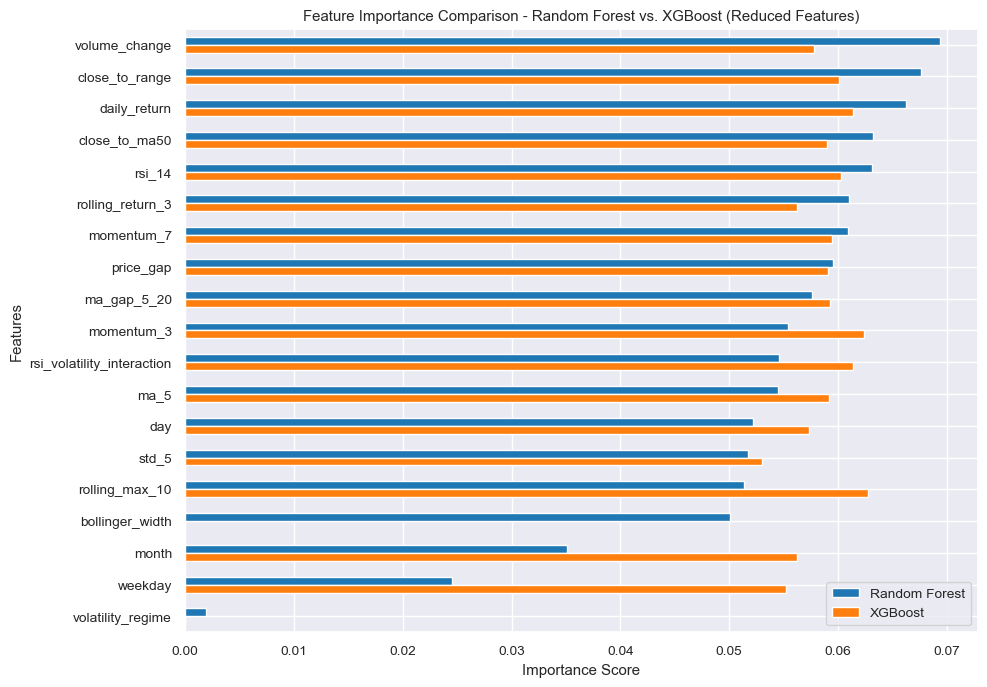

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("MSFT.csv", parse_dates=['date'])
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

# Feature Engineering (ensure all used features are created)
df['ma_5'] = df['close'].rolling(window=5).mean()
df['std_5'] = df['close'].rolling(window=5).std()
df['bollinger_width'] = 2 * df['std_5']
df['volatility_regime'] = (df['std_5'] > df['std_5'].median()).astype(int)
df['volume_change'] = df['volume'].pct_change()
df['daily_return'] = df['close'].pct_change()
df['rolling_return_3'] = df['daily_return'].rolling(window=3).sum()
df['momentum_3'] = df['close'] - df['close'].shift(3)
df['momentum_7'] = df['close'] - df['close'].shift(7)
df['rsi_14'] = df['close'].pct_change().rolling(14).apply(
    lambda x: 100 - 100 / (1 + (x[x > 0].sum() / (-x[x < 0].sum() + 1e-5))), raw=False)
df['rsi_volatility_interaction'] = df['rsi_14'] * df['std_5']
df['price_gap'] = df['open'] - df['close']
df['close_to_ma50'] = df['close'] / df['close'].rolling(window=50).mean()
df['ma_20'] = df['close'].rolling(window=20).mean()
df['ma_gap_5_20'] = df['ma_5'] - df['ma_20']
df['close_to_range'] = (df['close'] - df['low']) / (df['high'] - df['low'] + 1e-5)
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['rolling_max_10'] = df['close'].rolling(window=10).max()

# Target variable
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Drop missing values
df.dropna(inplace=True)

# Final confirmed feature set
feature_cols = [
    'ma_5', 'std_5', 'bollinger_width', 'volatility_regime',
    'volume_change', 'daily_return', 'rolling_return_3',
    'momentum_3', 'momentum_7', 'rsi_14', 'rsi_volatility_interaction',
    'price_gap', 'close_to_ma50', 'ma_gap_5_20', 'close_to_range',
    'weekday', 'month', 'day', 'rolling_max_10'
]
X_reduced = df[feature_cols]
y = df['target']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Fit models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_scaled, y)
rf_importance = rf_model.feature_importances_

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_scaled, y)
xgb_importance = xgb_model.feature_importances_

# Combine feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Random Forest': rf_importance,
    'XGBoost': xgb_importance
}).set_index('Feature').sort_values(by='Random Forest', ascending=False)

# Plot
importance_df.plot(kind='barh', figsize=(10, 7), color=['#1f77b4', '#ff7f0e'])
plt.title("Feature Importance Comparison - Random Forest vs. XGBoost (Reduced Features)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(True)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.savefig("Feature_Importance_RF_XGB_Reduced.png")
plt.show()

# Export to CSV
importance_df.reset_index().to_csv("Feature_Importance_Comparison_Reduced.csv", index=False)




In [42]:
from sklearn.preprocessing import StandardScaler

# ============================
# Select Top Features Based on RF + XGB
# ============================

# 1. Define how many top features to select from each model
top_n = 10

# 2. Get Top N Features from Random Forest
top_rf = importance_df['Random Forest'].nlargest(top_n).index.tolist()

# 3. Get Top N Features from XGBoost
top_xgb = importance_df['XGBoost'].nlargest(top_n).index.tolist()

# 4. Merge and deduplicate
combined_top_features = sorted(list(set(top_rf + top_xgb)))

# 5. Select final features from df
X_selected = df[combined_top_features]
y_selected = df['target']

# 6. Standardize
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# 7. Display selected features
print("Final Selected Features (Top 10 RF + XGB Combined):")
for f in combined_top_features:
    print("-", f)




Final Selected Features (Top 10 RF + XGB Combined):
- close_to_ma50
- close_to_range
- daily_return
- ma_5
- ma_gap_5_20
- momentum_3
- momentum_7
- price_gap
- rolling_max_10
- rolling_return_3
- rsi_14
- rsi_volatility_interaction
- volume_change


In [43]:
# ===============================
# Step 2: Use Top 10 Features from RF + XGB (Merged)
# ===============================

X = X_selected 
y = df['target']

# Chronological train-test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# Step 3: Train and Evaluate Final Models
# ===============================
models = [
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
]

summary = []

for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    summary.append({
        'Model': name,
        'ROC AUC': roc_auc_score(y_test, y_prob),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# ===============================
# Step 4: Create Evaluation Table
# ===============================
results_df = pd.DataFrame(summary)
print("\n=== Final Model Evaluation on Top 10 RF + XGB Features ===")
print(results_df.round(4))

# Save the evaluation table
results_df.to_csv("Final_Model_Evaluation_Top10Features.csv", index=False)





=== Final Model Evaluation on Top 10 RF + XGB Features ===
           Model  ROC AUC  Accuracy  Precision  Recall  F1 Score
0  Random Forest   0.5354    0.5010     0.5674  0.3214    0.4103
1        XGBoost   0.5168    0.5031     0.5468  0.4684    0.5046


c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Random Forest Evaluation ===


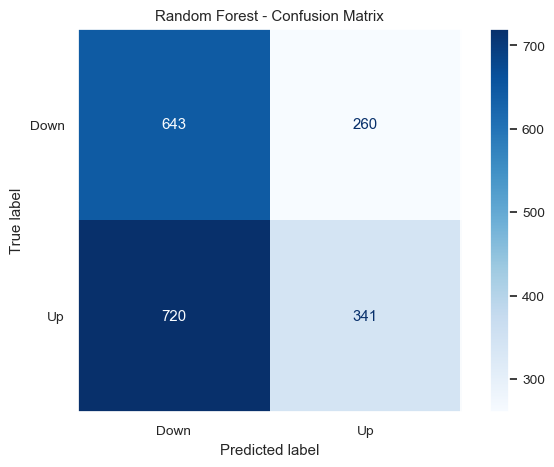

              precision    recall  f1-score   support

        Down       0.47      0.71      0.57       903
          Up       0.57      0.32      0.41      1061

    accuracy                           0.50      1964
   macro avg       0.52      0.52      0.49      1964
weighted avg       0.52      0.50      0.48      1964



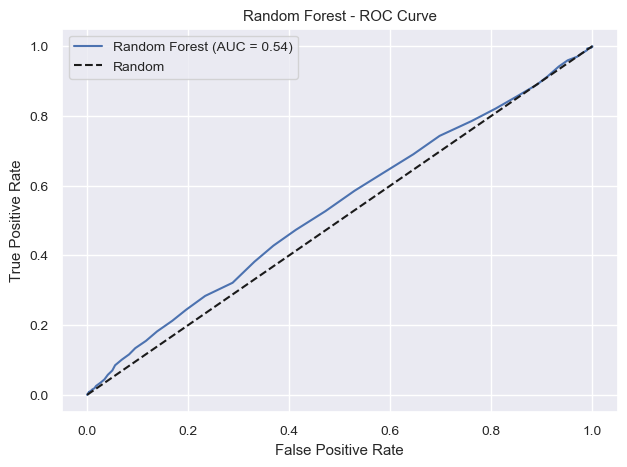

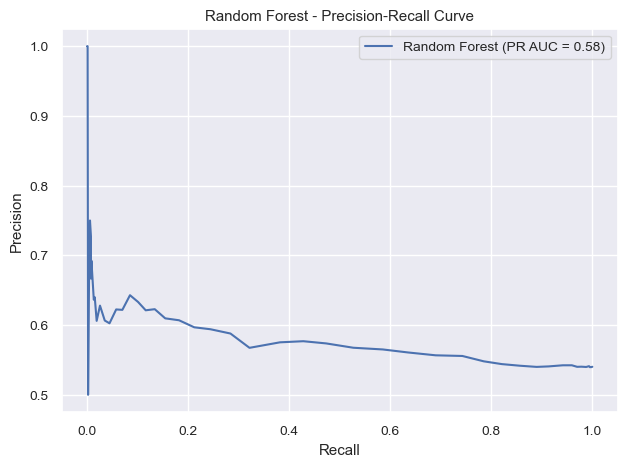


=== XGBoost Evaluation ===


c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:13:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


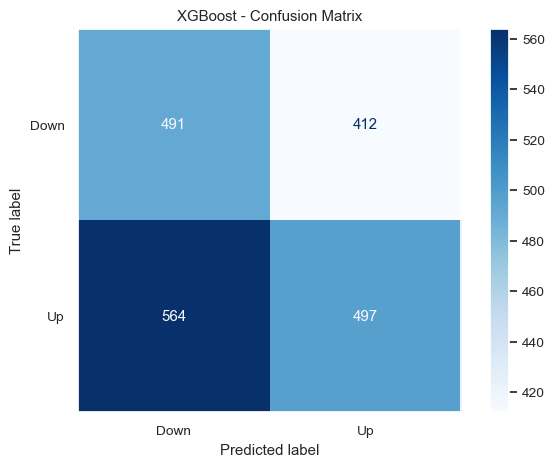

              precision    recall  f1-score   support

        Down       0.47      0.54      0.50       903
          Up       0.55      0.47      0.50      1061

    accuracy                           0.50      1964
   macro avg       0.51      0.51      0.50      1964
weighted avg       0.51      0.50      0.50      1964



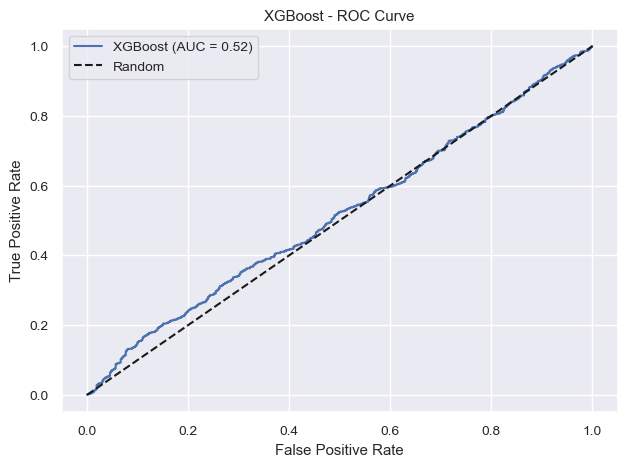

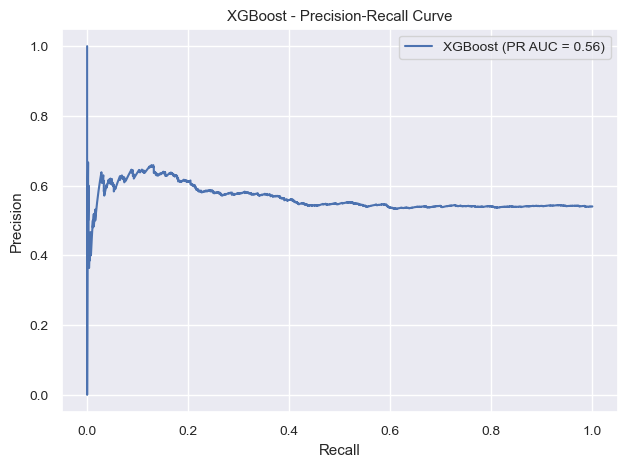

c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classificati

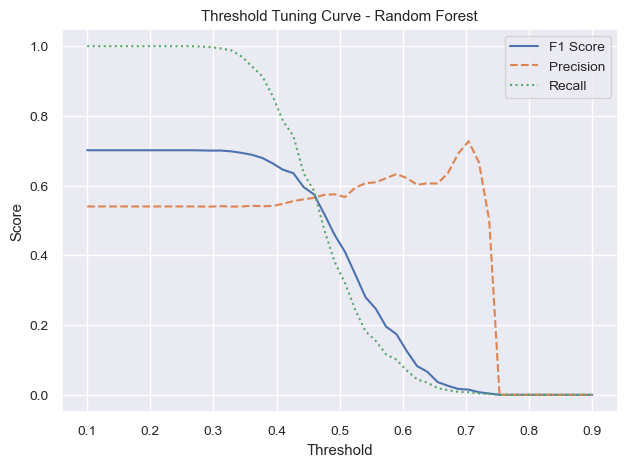

c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:14:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


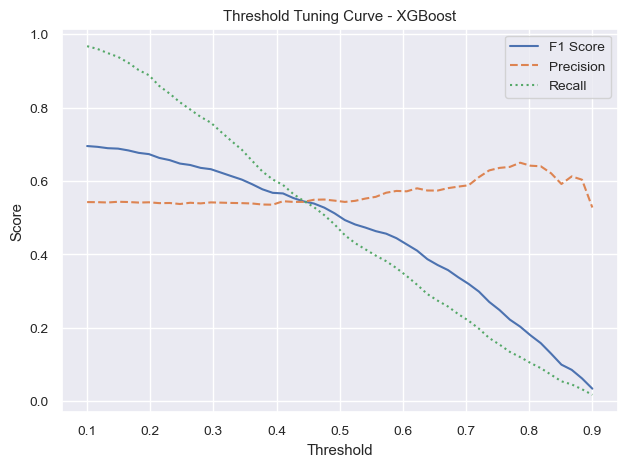


=== Random Forest Evaluation ===


c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\RSM\anaconda3\Lib\site-packages\sklearn\metrics\_classificati


=== XGBoost Evaluation ===


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score
)

X = X_selected
y = df['target']

# Chronological train-test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# Define and Train Models
# =========================
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    print(f"\n=== {name} Evaluation ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # === Confusion Matrix ===
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{name} - Confusion Matrix')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"{name}_Confusion_Matrix_Selected_Features.png")
    plt.show()

    # === Classification Report ===
    print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

    # === ROC Curve ===
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{name}_ROC_Curve_Selected_Features.png")
    plt.show()

    # === (Optional) Precision-Recall Curve ===
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure()
    plt.plot(recall, precision, label=f'{name} (PR AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{name} - Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{name}_PR_Curve_Selected_Features.png")
    plt.show()

# ===============================
# (Optional) Threshold Tuning Plot
# ===============================
thresholds = np.linspace(0.1, 0.9, 50)
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]

    f1_scores, precisions, recalls = [], [], []
    for t in thresholds:
        y_thresh = (y_probs >= t).astype(int)
        f1_scores.append(f1_score(y_test, y_thresh))
        precisions.append(precision_score(y_test, y_thresh))
        recalls.append(recall_score(y_test, y_thresh))

    plt.figure()
    plt.plot(thresholds, f1_scores, label='F1 Score')
    plt.plot(thresholds, precisions, label='Precision', linestyle='--')
    plt.plot(thresholds, recalls, label='Recall', linestyle=':')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title(f'Threshold Tuning Curve - {name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{name}_Threshold_Tuning_Curve.png")
    plt.show()

# Create folders to store exported data
import os
os.makedirs("tableau_exports", exist_ok=True)

thresholds = np.linspace(0.1, 0.9, 50)

for name, model in models.items():
    print(f"\n=== {name} Evaluation ===")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # ==== 1. Confusion Matrix Export ====
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, columns=['Predicted Down', 'Predicted Up'], index=['Actual Down', 'Actual Up'])
    cm_df.reset_index(inplace=True)
    cm_df.to_csv(f"tableau_exports/{name}_ConfusionMatrix.csv", index=False)

    # ==== 2. ROC Curve Export ====
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_df = pd.DataFrame({'False Positive Rate': fpr, 'True Positive Rate': tpr})
    roc_df['Model'] = name
    roc_df.to_csv(f"tableau_exports/{name}_ROC.csv", index=False)

    # ==== 3. PR Curve Export ====
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_df = pd.DataFrame({'Recall': recall, 'Precision': precision})
    pr_df['Model'] = name
    pr_df.to_csv(f"tableau_exports/{name}_PR.csv", index=False)

    # ==== 4. Threshold Tuning Export ====
    tuning_data = []
    for t in thresholds:
        y_thresh = (y_prob >= t).astype(int)
        tuning_data.append({
            'Threshold': t,
            'F1 Score': f1_score(y_test, y_thresh),
            'Precision': precision_score(y_test, y_thresh),
            'Recall': recall_score(y_test, y_thresh),
            'Model': name
        })
    tuning_df = pd.DataFrame(tuning_data)
    tuning_df.to_csv(f"tableau_exports/{name}_ThresholdTuning.csv", index=False)

    # ==== 5. Classification Report Export ====
    report = classification_report(y_test, y_pred, target_names=['Down', 'Up'], output_dict=True)
    report_df = pd.DataFrame(report).T.reset_index().rename(columns={'index': 'Class'})
    report_df['Model'] = name
    report_df.to_csv(f"tableau_exports/{name}_ClassificationReport.csv", index=False)


In [45]:
#Hyperparameter Tuning using RandomSearchCV for Random Forest and XGboost

import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

X = X_selected
y = df['target']

# === Scaling ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === CV Setup ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === RF Param Grid ===
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# === XGB Param Grid ===
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# === RF Randomized Search ===
rf = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# === XGB Randomized Search ===
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# === Fit Models ===
rf_search.fit(X_scaled, y)
xgb_search.fit(X_scaled, y)

# === Output Best Parameters ===
print("\nBest Random Forest Parameters:")
print(rf_search.best_params_)
print("Best ROC AUC Score:", rf_search.best_score_)

print("\nBest XGBoost Parameters:")
print(xgb_search.best_params_)
print("Best ROC AUC Score:", xgb_search.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Random Forest Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': False}
Best ROC AUC Score: 0.5357896710227978

Best XGBoost Parameters:
{'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best ROC AUC Score: 0.5410766743424679


c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:15:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Ensure DataFrame is sorted and clean
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
df.dropna(inplace=True)

# Final selected features from top 10 RF + XGB
X = X_selected
y = df['target']

# Chronological split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# Retrain Tuned Random Forest
# -------------------------
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=4,
    bootstrap=False,
    random_state=42
)
best_rf.fit(X_train_scaled, y_train)
rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]
rf_preds = best_rf.predict(X_test_scaled)
print("=== Tuned Random Forest ===")
print("ROC AUC:", roc_auc_score(y_test, rf_probs))
print(classification_report(y_test, rf_preds))

# -------------------------
# Retrain Tuned XGBoost
# -------------------------
best_xgb = XGBClassifier(
    subsample=0.6,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    colsample_bytree=0.6,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
best_xgb.fit(X_train_scaled, y_train)
xgb_probs = best_xgb.predict_proba(X_test_scaled)[:, 1]
xgb_preds = best_xgb.predict(X_test_scaled)
print("\n=== Tuned XGBoost ===")
print("ROC AUC:", roc_auc_score(y_test, xgb_probs))
print(classification_report(y_test, xgb_preds))


=== Tuned Random Forest ===
ROC AUC: 0.5389752244847262
              precision    recall  f1-score   support

           0       0.48      0.77      0.59       903
           1       0.60      0.30      0.40      1061

    accuracy                           0.51      1964
   macro avg       0.54      0.53      0.49      1964
weighted avg       0.54      0.51      0.49      1964


=== Tuned XGBoost ===
ROC AUC: 0.5429435654322226
              precision    recall  f1-score   support

           0       0.48      0.65      0.55       903
           1       0.58      0.41      0.48      1061

    accuracy                           0.52      1964
   macro avg       0.53      0.53      0.51      1964
weighted avg       0.53      0.52      0.51      1964



c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:15:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


c:\Users\RSM\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:15:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


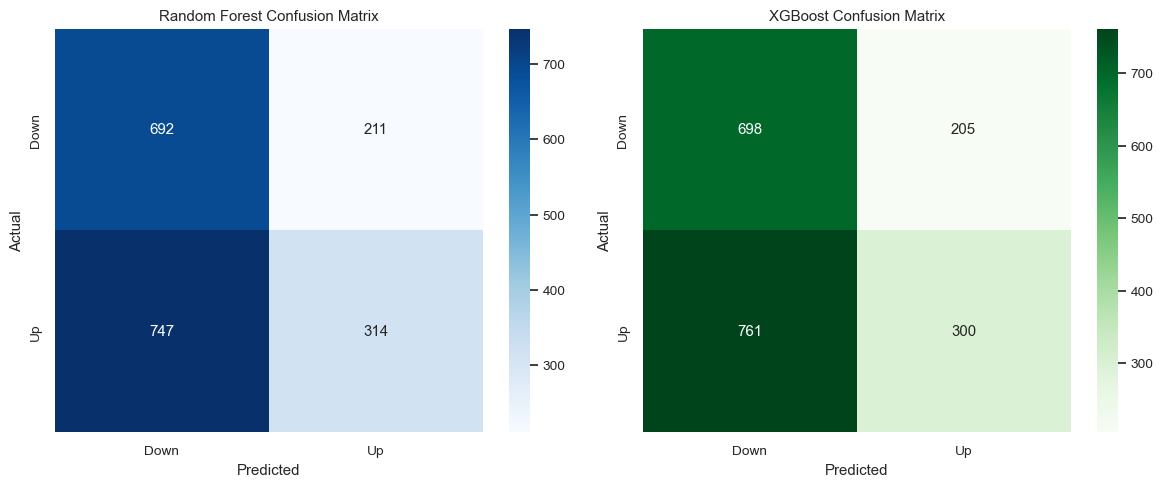

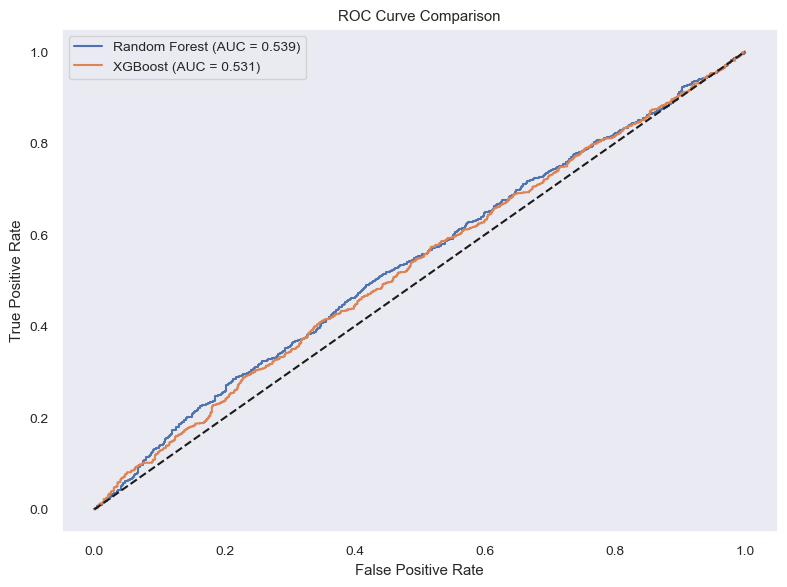

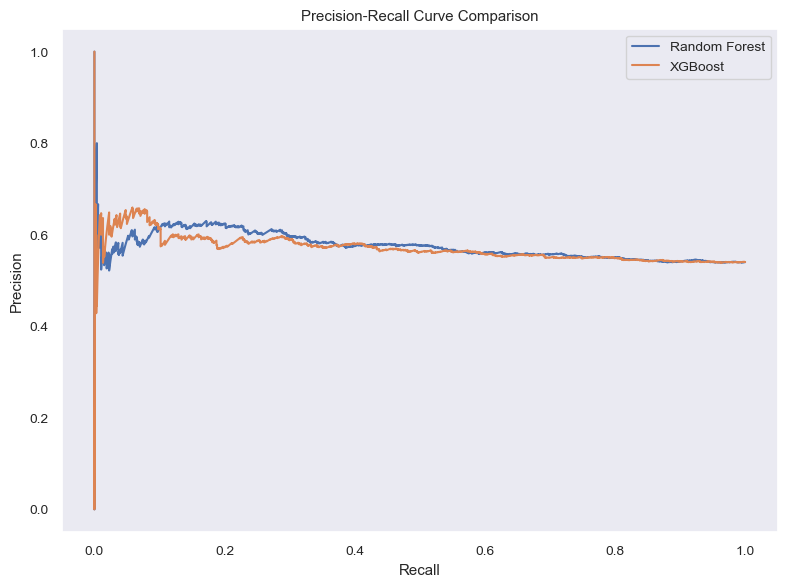

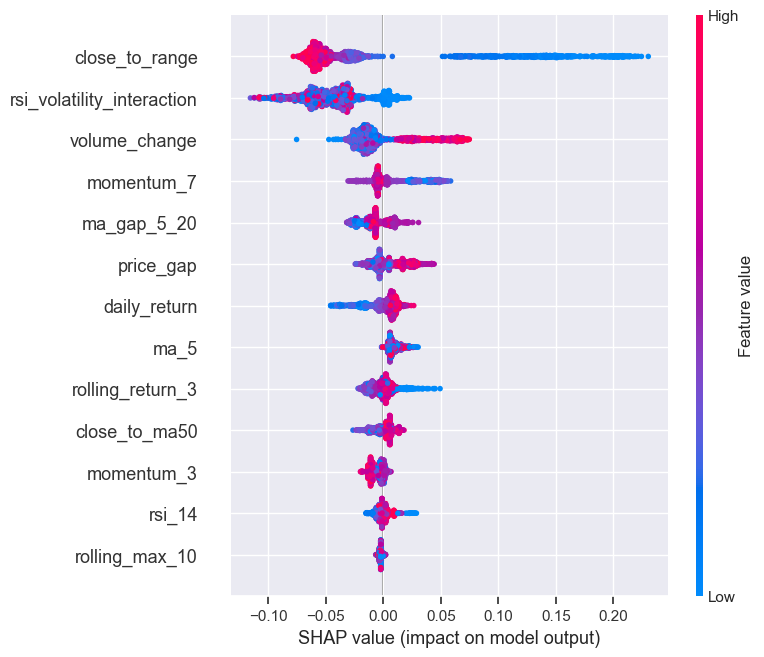

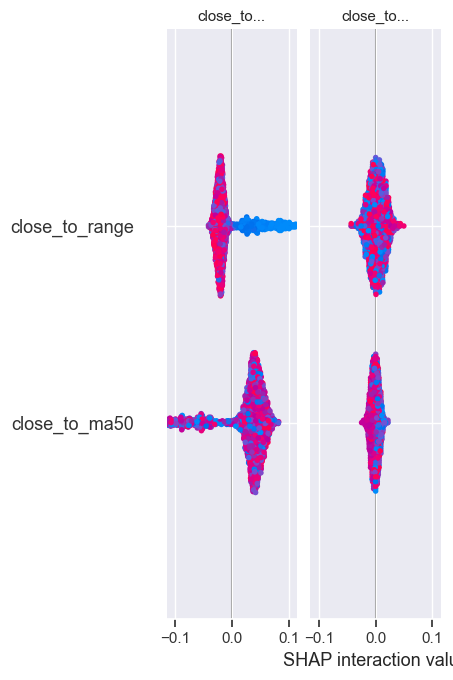

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Ensure DataFrame is sorted and clean
df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
df.dropna(inplace=True)

# Final selected features from top 10 RF + XGB
X = X_selected
y = df['target']

# Chronological split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# === Train Random Forest (Tuned Params) ===
rf_final = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_depth=10,
    bootstrap=False,
    random_state=42
)
rf_final.fit(X_train_scaled, y_train)

# === Train XGBoost (Tuned Params) ===
xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_final.fit(X_train_scaled, y_train)

# === Predictions ===
y_pred_rf = rf_final.predict(X_test_scaled)
y_prob_rf = rf_final.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = xgb_final.predict(X_test_scaled)
y_prob_xgb = xgb_final.predict_proba(X_test_scaled)[:, 1]

# === Confusion Matrix Comparison ===
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title("Random Forest Confusion Matrix")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("Actual")
axs[0].set_xticklabels(['Down', 'Up'])
axs[0].set_yticklabels(['Down', 'Up'])

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axs[1])
axs[1].set_title("XGBoost Confusion Matrix")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("Actual")
axs[1].set_xticklabels(['Down', 'Up'])
axs[1].set_yticklabels(['Down', 'Up'])

plt.tight_layout()
plt.show()

# === ROC Curve Comparison ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# === Precision-Recall Curve Comparison ===
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, label="Random Forest")
plt.plot(recall_xgb, precision_xgb, label="XGBoost")
plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# === SHAP Summary Plot for XGBoost (CPU-Safe) ===
explainer_xgb = shap.Explainer(xgb_final)
shap_values_xgb = explainer_xgb(X_test_scaled)
shap.summary_plot(shap_values_xgb.values, X_test_scaled, feature_names=X.columns)

# === SHAP Summary Plot for Random Forest ===
explainer_rf = shap.Explainer(rf_final)
shap_values_rf = explainer_rf(X_test_scaled)
shap.summary_plot(shap_values_rf.values, X_test_scaled, feature_names=X.columns)
